/var/folders/rv/q52q8kmj0s558xpyhlshtzw00000gn/T/ipykernel_61853/2606932174.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


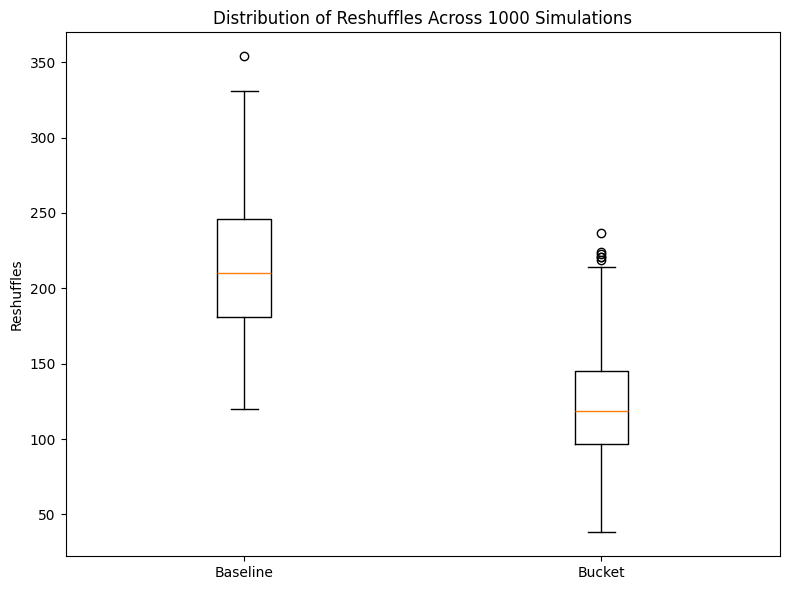

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/kellyg/eurogate-twin-1/simulation_batch_results.csv")

plt.figure(figsize=(8,6))

plt.boxplot(
    [
        df["baseline_reshuffles"],
        df["bucket_reshuffles"]
    ],
    labels=["Baseline", "Bucket"]
)

plt.ylabel("Reshuffles")
plt.title("Distribution of Reshuffles Across 1000 Simulations")

plt.tight_layout()
plt.show()

/var/folders/rv/q52q8kmj0s558xpyhlshtzw00000gn/T/ipykernel_61853/343433270.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


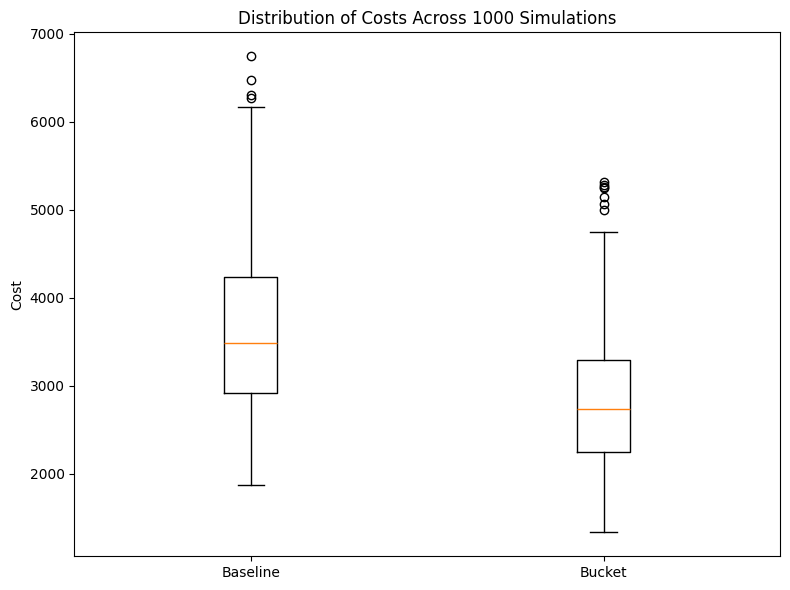

In [4]:
# import pandas as pd
# import matplotlib.pyplot as plt

# df = pd.read_csv("simulation_batch_results.csv")

plt.figure(figsize=(8,6))

plt.boxplot(
    [
        df["baseline_cost"],
        df["bucket_cost"]
    ],
    labels=["Baseline", "Bucket"]
)

plt.ylabel("Cost")
plt.title("Distribution of Costs Across 1000 Simulations")

plt.tight_layout()
plt.show()

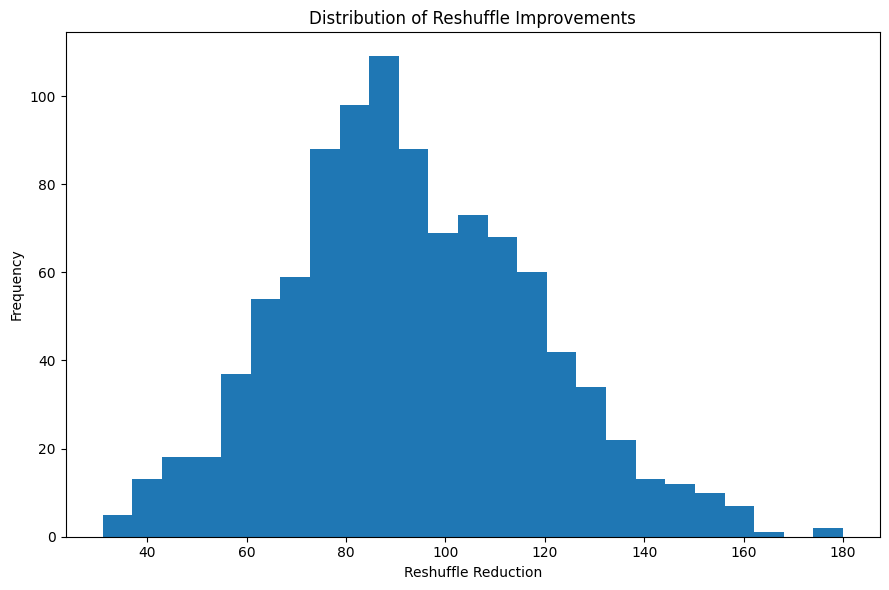

In [6]:
plt.figure(figsize=(9,6))

plt.hist(
    df["reshuffle_reduction"],
    bins=25
)

plt.xlabel("Reshuffle Reduction")
plt.ylabel("Frequency")
plt.title("Distribution of Reshuffle Improvements")

plt.tight_layout()
plt.show()

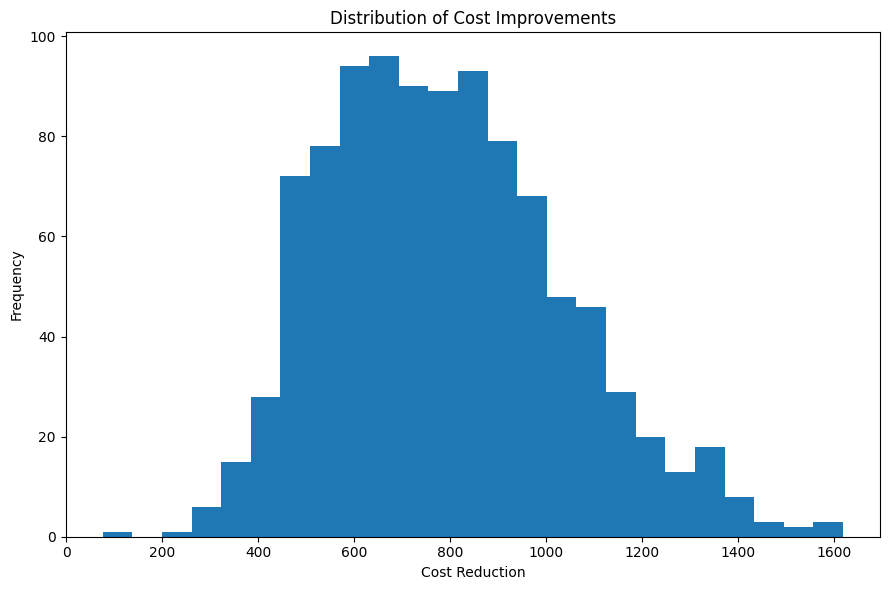

In [8]:
plt.figure(figsize=(9,6))

plt.hist(
    df["cost_reduction"],
    bins=25
)

plt.xlabel("Cost Reduction")
plt.ylabel("Frequency")
plt.title("Distribution of Cost Improvements")

plt.tight_layout()
plt.show()

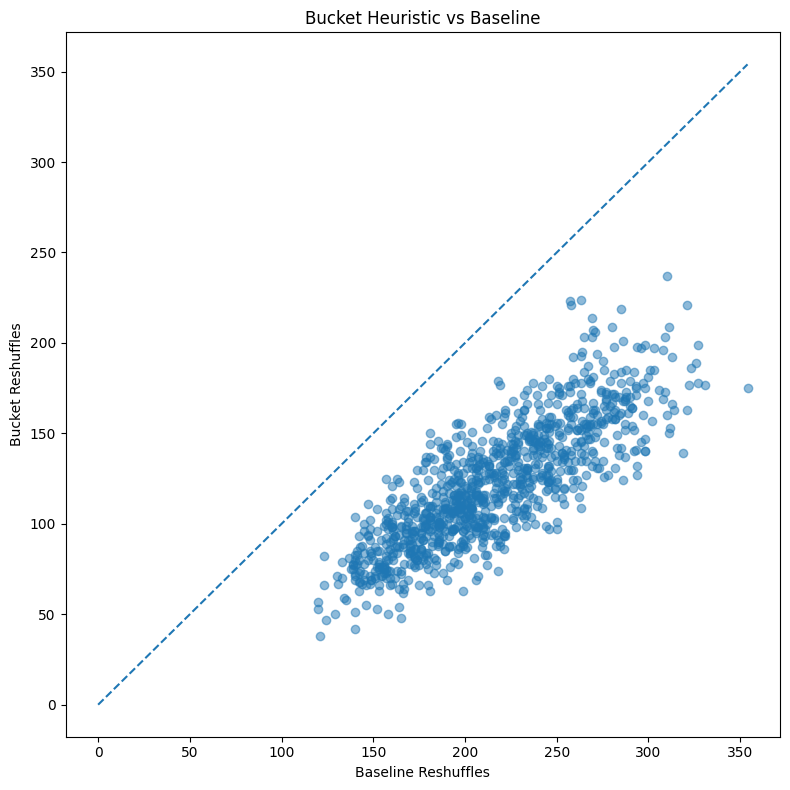

In [9]:

plt.figure(figsize=(8,8))

plt.scatter(
    df["baseline_reshuffles"],
    df["bucket_reshuffles"],
    alpha=0.5
)

max_val = max(
    df["baseline_reshuffles"].max(),
    df["bucket_reshuffles"].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    '--'
)

plt.xlabel("Baseline Reshuffles")
plt.ylabel("Bucket Reshuffles")
plt.title("Bucket Heuristic vs Baseline")

plt.tight_layout()
plt.show()

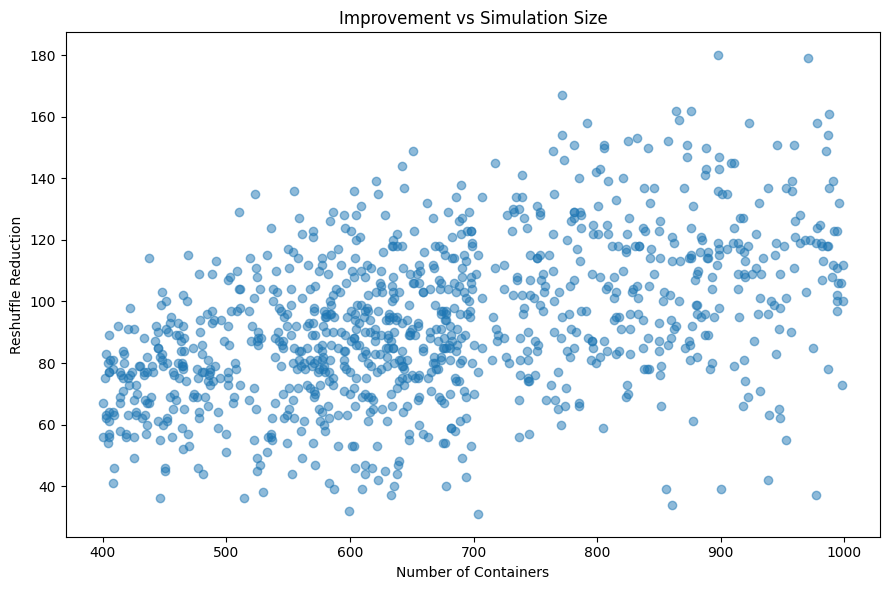

In [10]:
plt.figure(figsize=(9,6))

plt.scatter(
    df["containers"],
    df["reshuffle_reduction"],
    alpha=0.5
)

plt.xlabel("Number of Containers")
plt.ylabel("Reshuffle Reduction")
plt.title("Improvement vs Simulation Size")

plt.tight_layout()
plt.show()

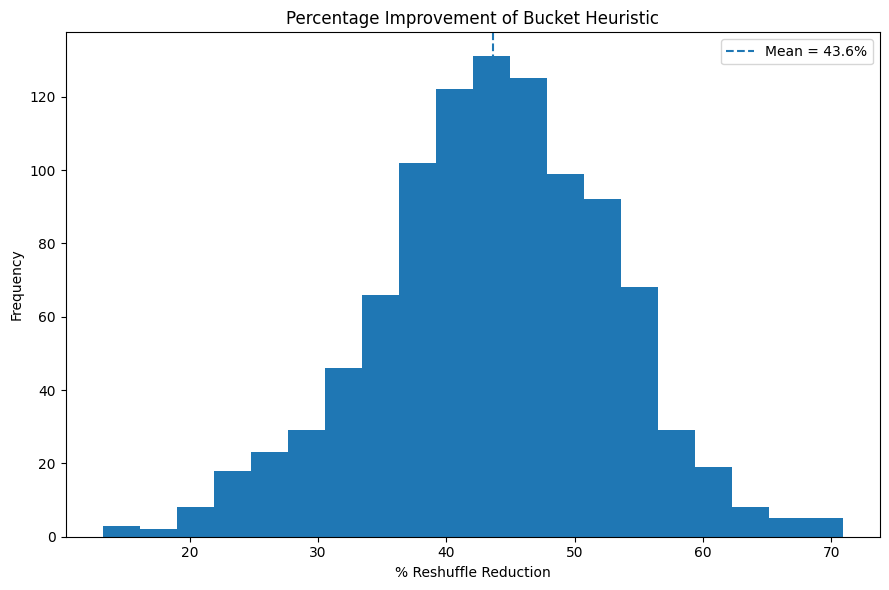

In [12]:
plt.figure(figsize=(9,6))

plt.hist(
    df["reshuffle_pct_reduction"],
    bins=20
)

plt.axvline(
    df["reshuffle_pct_reduction"].mean(),
    linestyle="--",
    label=f"Mean = {df['reshuffle_pct_reduction'].mean():.1f}%"
)

plt.xlabel("% Reshuffle Reduction")
plt.ylabel("Frequency")
plt.title("Percentage Improvement of Bucket Heuristic")
plt.legend()

plt.tight_layout()
plt.show()

/var/folders/rv/q52q8kmj0s558xpyhlshtzw00000gn/T/ipykernel_61853/1499474729.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(


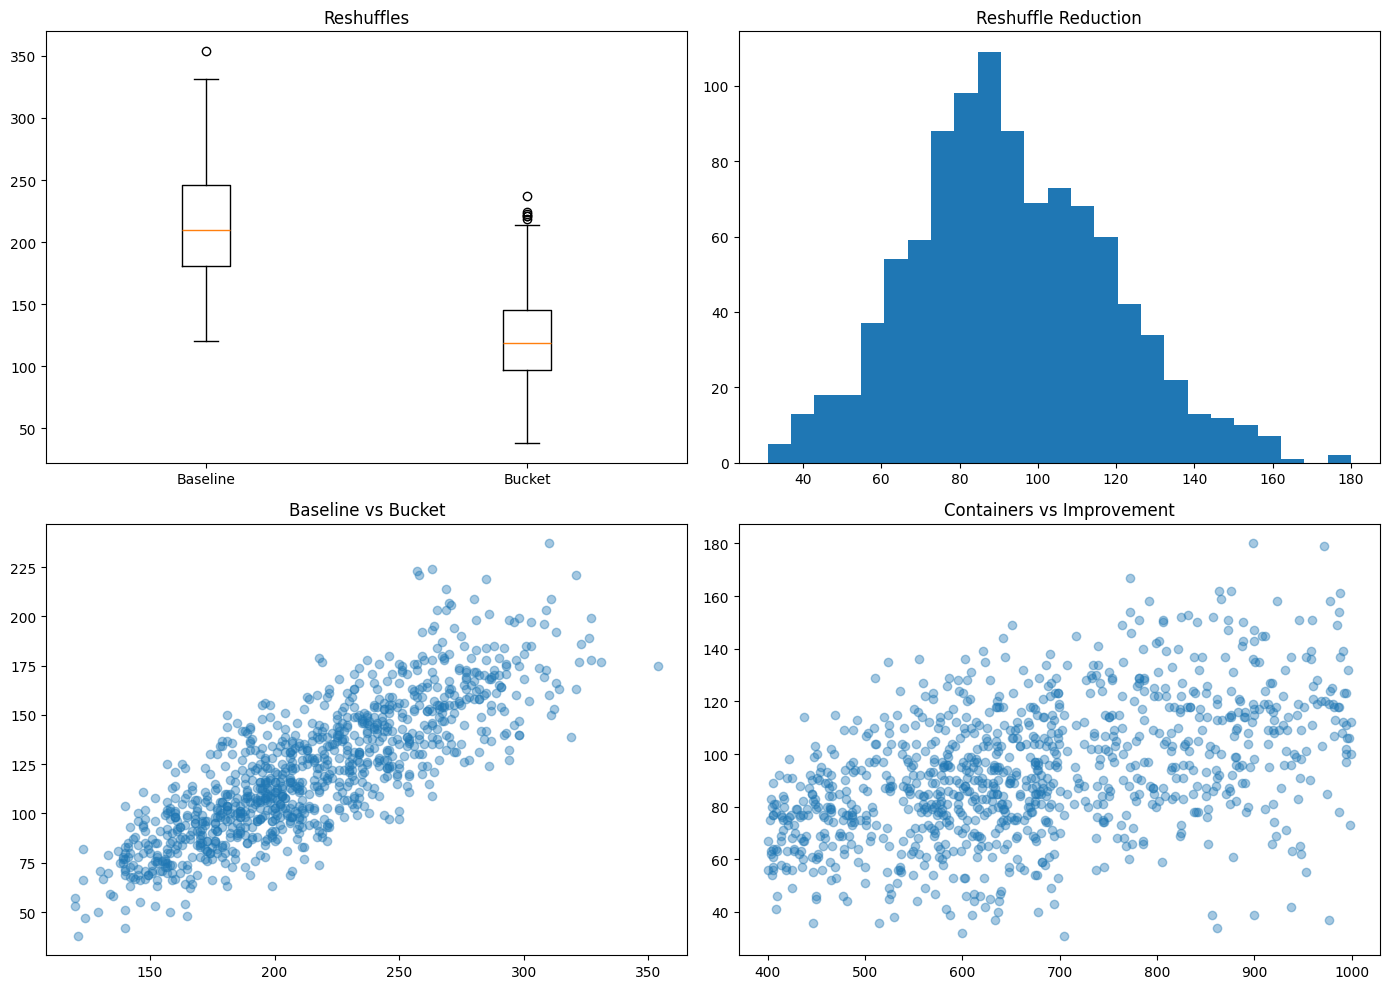

In [13]:

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# Boxplot
axes[0,0].boxplot(
    [
        df["baseline_reshuffles"],
        df["bucket_reshuffles"]
    ],
    labels=["Baseline","Bucket"]
)
axes[0,0].set_title("Reshuffles")

# Histogram
axes[0,1].hist(
    df["reshuffle_reduction"],
    bins=25
)
axes[0,1].set_title("Reshuffle Reduction")

# Scatter
axes[1,0].scatter(
    df["baseline_reshuffles"],
    df["bucket_reshuffles"],
    alpha=0.4
)
axes[1,0].set_title("Baseline vs Bucket")

# Containers
axes[1,1].scatter(
    df["containers"],
    df["reshuffle_reduction"],
    alpha=0.4
)
axes[1,1].set_title("Containers vs Improvement")

plt.tight_layout()
plt.show()

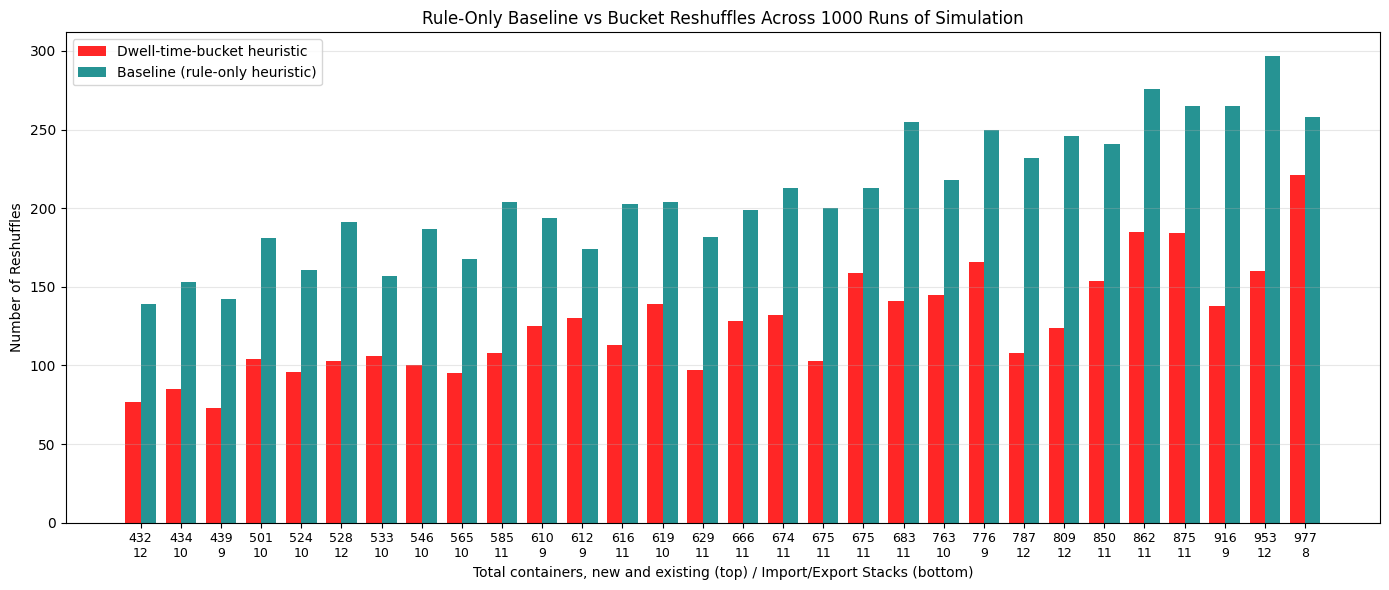

In [23]:
import numpy as np
plot_df = df.sample(n=30, random_state=13).sort_values("containers")

# X positions
x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

# Bars
plt.bar(
    x - width/2,
    plot_df["bucket_reshuffles"],
    width,
    label="Dwell-time-bucket heuristic",
    color="red",
    alpha=0.85
)

plt.bar(
    x + width/2,
    plot_df["baseline_reshuffles"],
    width,
    label="Baseline (rule-only heuristic)",
    color="teal",
    alpha=0.85
)


# X-axis labels: combine containers + stacks
xtick_labels = [
    f"{c}\n{s}"
    for c, s in zip(
        plot_df["containers"],
        plot_df["import_stacks"]
    )
]

plt.xticks(x, xtick_labels, rotation=0, fontsize=9)

plt.xlabel("Total containers, new and existing (top) / Import/Export Stacks (bottom)")
plt.ylabel("Number of Reshuffles")
plt.title("Rule-Only Baseline vs Bucket Reshuffles Across 1000 Runs of Simulation")
plt.legend()

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()